# 06. Matplotlib 기초 - 실습 문제

## 실습 안내
- 총 8개 문제
- Matplotlib 기본 차트 연습
- 스타일링과 커스터마이징 연습

## 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)

# 데이터 로드
production_df = pd.read_csv('../data/05_production.csv', encoding='utf-8-sig')
quality_df = pd.read_csv('../data/07_quality_inspection.csv', encoding='utf-8-sig', na_values=['\\N'])
equipment_df = pd.read_csv('../data/01_equipment.csv', encoding='utf-8-sig')

# 날짜 변환
production_df['production_date'] = pd.to_datetime(production_df['production_date'])
quality_df['inspection_time'] = pd.to_datetime(quality_df['inspection_time'])

# 불량률 계산
production_df['defect_rate'] = (production_df['defect_quantity'] / production_df['actual_quantity'] * 100).round(2)

from koreanize_matplotlib import koreanize
koreanize()

print("데이터 로드 완료!")

데이터 로드 완료!


---
## 문제 1: 제품별 총 생산량 그래프 (10점)

**요구사항**:
1. 제품별 총 생산량 집계 및 내림차순 정렬
2. 제목: '제품별 총 생산량'
3. x축 레이블 45도 회전

**힌트**: `groupby()`, `plt.xticks(rotation=45)`

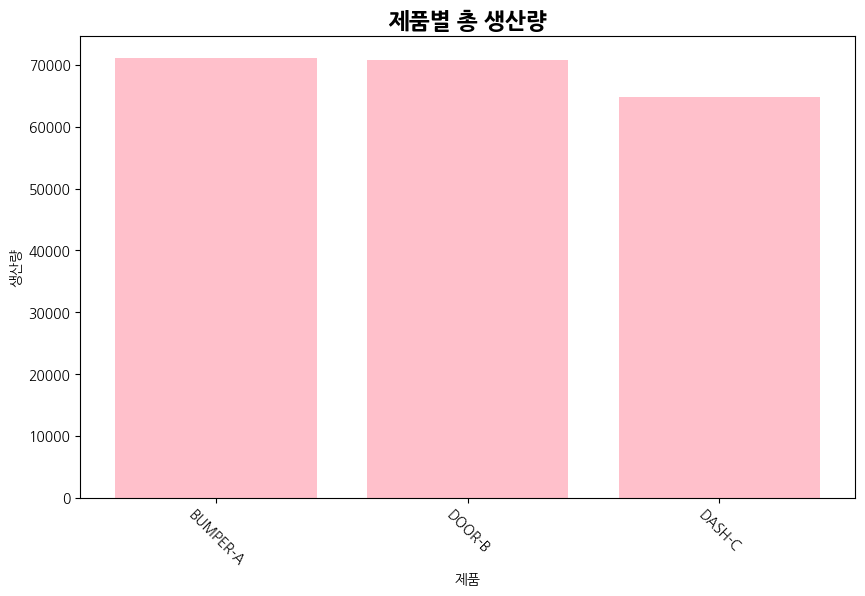

In [18]:
# 여기에 코드 작성
product_cnt = production_df.groupby('product_code')['actual_quantity'].sum()
product_cnt = product_cnt.sort_values(ascending = False)

plt.bar(product_cnt.index, product_cnt.values, color = 'pink')

plt.title('제품별 총 생산량', fontsize = 16, fontweight = 'bold')
plt.xticks(rotation = -45)
plt.xlabel('제품')
plt.ylabel('생산량')

plt.show()

---
## 문제 2: 일별 불량률 추이 선 그래프 (15점)

**요구사항**:
1. 일별 평균 불량률 집계 (처음 30일)
2. 제목: '일별 평균 불량률 추이 (30일)'
3. x축 레이블 45도 회전

**힌트**: `groupby()`, `head(30)`

In [29]:
# 여기에 코드 작성
production_df['불량률'] = (production_df['defect_quantity'] / production_df['actual_quantity'] * 100).round(2)

end_date = production_df['production_date'].min() + pd.Timedelta(days = 30)
production_df30 = production_df[production_df['production_date'] <= end_date]

production_df30 = production_df30.set_index('production_date').resample('D')['불량률'].mean()

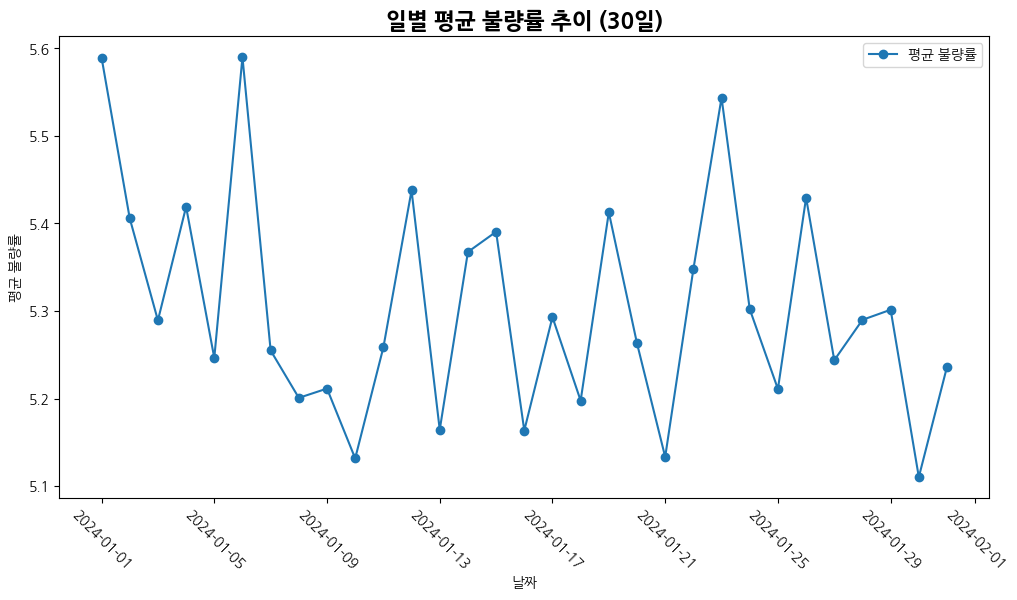

In [33]:
plt.figure(figsize = (12,6))
plt.plot(production_df30.index, production_df30.values,
        marker = 'o',
        label = '평균 불량률')
plt.title('일별 평균 불량률 추이 (30일)', fontsize = 16, fontweight='bold')
plt.xticks(rotation=-45)
plt.xlabel('날짜')
plt.ylabel('평균 불량률')
plt.legend()
plt.show()

---
## 문제 3: 설비별 평균 사이클 타임 가로 bar 그래프 (10점)

**요구사항**:
1. 설비별 평균 사이클 타임 집계
2. 사이클 타임 내림차순 정렬 (상위 10개)
3. 가로 그래프 생성
4. 제목: '설비별 평균 사이클 타임 (상위 10개)'
5. x축 격자 추가



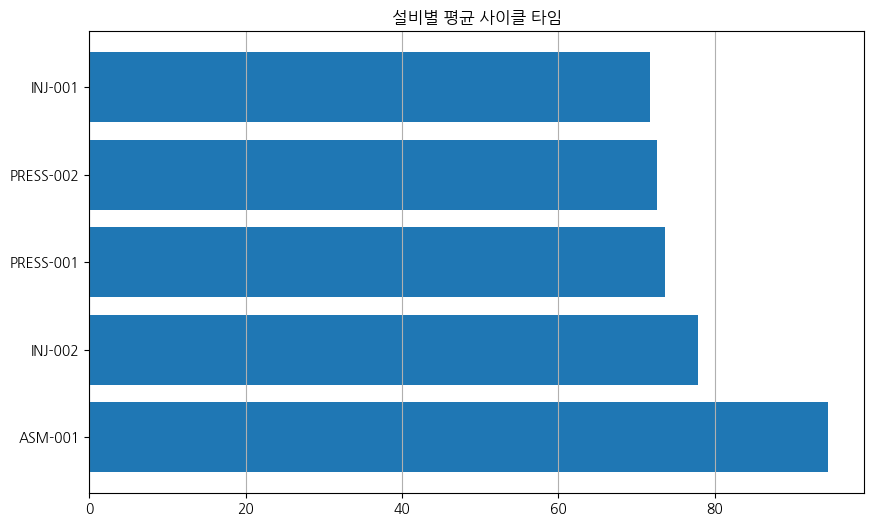

In [49]:
# 여기에 코드 작성
equip_cycle = production_df.groupby('equipment_id')['cycle_time'].mean()
equip_cycle = equip_cycle.sort_values(ascending = False).head(10)
plt.barh(equip_cycle.index, equip_cycle.values)
plt.title('설비별 평균 사이클 타임')
plt.grid(axis='x')
plt.show()

---
## 문제 4: 사이클 타임 분포 그리기 (15점)

**요구사항**:
1. 사이클 타임 (bins=40)
2. 막대 색상: 'lightgreen', 테두리: 'black'
3. 평균값을 빨간 점선으로 표시 (linewidth=2)
4. 중앙값을 파란 점선으로 표시 (linewidth=2)
5. 제목: '사이클 타임 분포'
6. 범례 추가 (평균: XX초, 중앙값: XX초)
7. y축 격자 추가

**힌트**: `plt.axvline()`

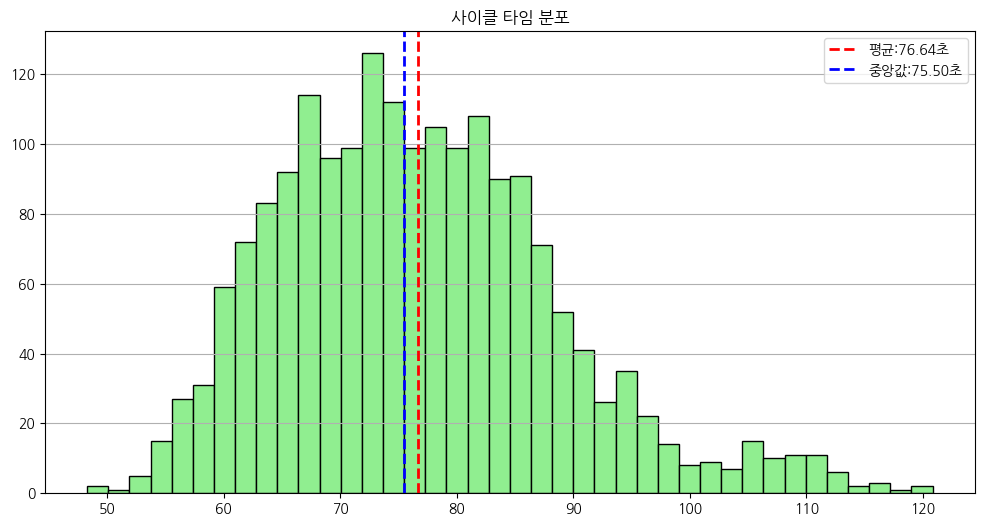

In [57]:
# 여기에 코드 작성
plt.figure(figsize = (12,6))
cycle = production_df['cycle_time']
plt.hist(cycle, bins = 40,
         color = 'lightgreen',
        edgecolor = 'black')
plt.axvline(cycle.mean(), color = 'red', 
            linestyle = '--', 
            linewidth = 2,
            label = f'평균:{cycle.mean():.2f}초')
plt.axvline(cycle.median(), color = 'blue', 
            linestyle = '--', 
            linewidth = 2,
            label = f'중앙값:{cycle.median():.2f}초')

plt.title('사이클 타임 분포')
plt.legend()
plt.grid(axis='y')
plt.show()

---
## 문제 5: 생산량 vs 사이클 타임 차트 (15점)

**요구사항**:
1. 실제 생산량(x축) vs 사이클 타임(y축) 
2. 교대조별로 색상 구분 (for loop 사용)
3. 제목: '생산량 vs 사이클 타임 (교대조별)'
4. 범례 추가

**힌트**: `for shift in df['shift'].unique()`

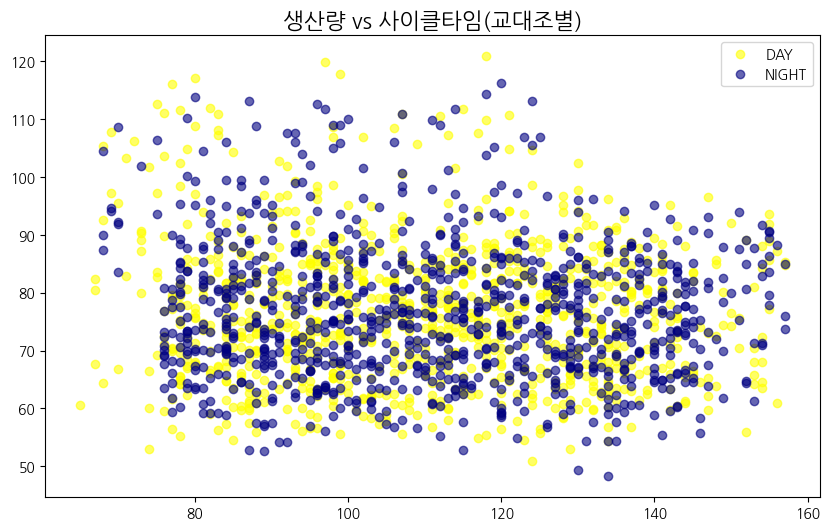

In [94]:
# 여기에 코드 작성
import matplotlib.cm as cm

shifts = production_df['shift'].unique()
colors = ['yellow', 'navy']

for shift, color in zip(shifts, colors):
    prod_shift = production_df[production_df['shift'] == shift]
    plt.scatter(prod_shift['actual_quantity'], 
                prod_shift['cycle_time'],
                alpha = 0.6,
                color = color,
                label = shift)
    plt.legend()


plt.title('생산량 vs 사이클타임(교대조별)', fontsize = 16)
plt.legend()
plt.show()

---
## 문제 6: 제품별 생산 비율 차트 (10점)

**요구사항**:
1. 제품별 생산 건수 집계
2. 차트 생성 : 퍼센트 표시 
3. 제목: '제품별 생산 건수 비율'
4. Figure 크기: (8, 8)



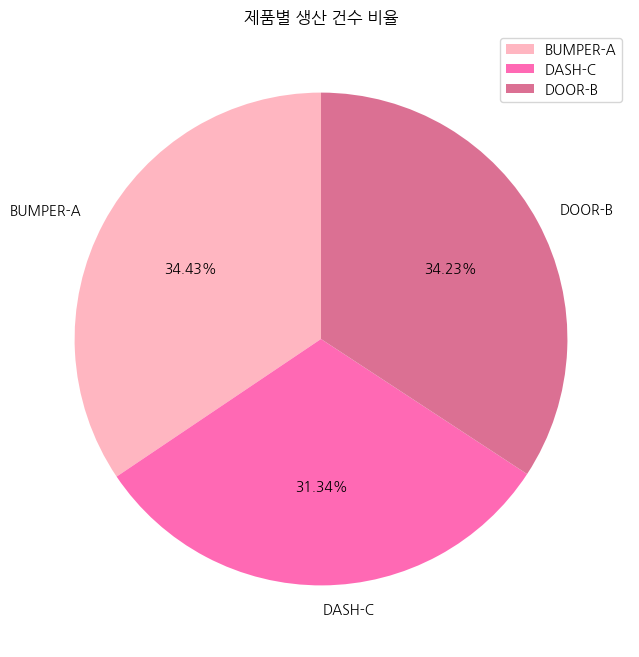

In [77]:
# 여기에 코드 작성
plt.figure(figsize = (8,8))
colors = ['#FFB6C1', '#FF69B4', '#DB7093']
prod_production = production_df.groupby('product_code')['actual_quantity'].sum()
plt.pie(prod_production, labels=prod_production.index, startangle=90, autopct='%.2f%%', colors=colors)
plt.title('제품별 생산 건수 비율')
plt.legend()
plt.show()

---
## 문제 7: 교대조별 일별 생산량 비교 선 그래프 (15점)

**요구사항**:
1. 교대조-날짜별 총 생산량 집계 (처음 30일)
2. 주간조와 야간조를 각각 다른 선으로 표시:
   - 주간조: 파란색, 마커 'o'
   - 야간조: 주황색, 마커 's'
3. 선 굵기: 2, 마커 크기: 4
4. 제목: '교대조별 일별 생산량 비교 (30일)'
5. 범례 추가
6. 격자 추가
7. x축 레이블 45도 회전



In [79]:
production_df.head(2)

,production_id,equipment_id,product_code,production_date,start_time,end_time,target_quantity,actual_quantity,good_quantity,defect_quantity,cycle_time,work_order_no,lot_no,operator_id,shift,created_at,updated_at,defect_rate,불량률
0,1,INJ-001,BUMPER-A,2024-01-01,2024-01-01 08:14:00,2024-01-01 09:53:32,97,81,77,4,73.73,WO202401019935,LOT2024010100101,OP003,DAY,2026-01-30 00:42:48,2026-01-30 00:42:48,4.94,4.94
1,2,INJ-001,BUMPER-A,2024-01-01,2024-01-01 21:02:00,2024-01-01 22:33:43,83,78,72,6,70.56,WO202401012535,LOT2024010100110,OP006,NIGHT,2026-01-30 00:42:48,2026-01-30 00:42:48,7.69,7.69


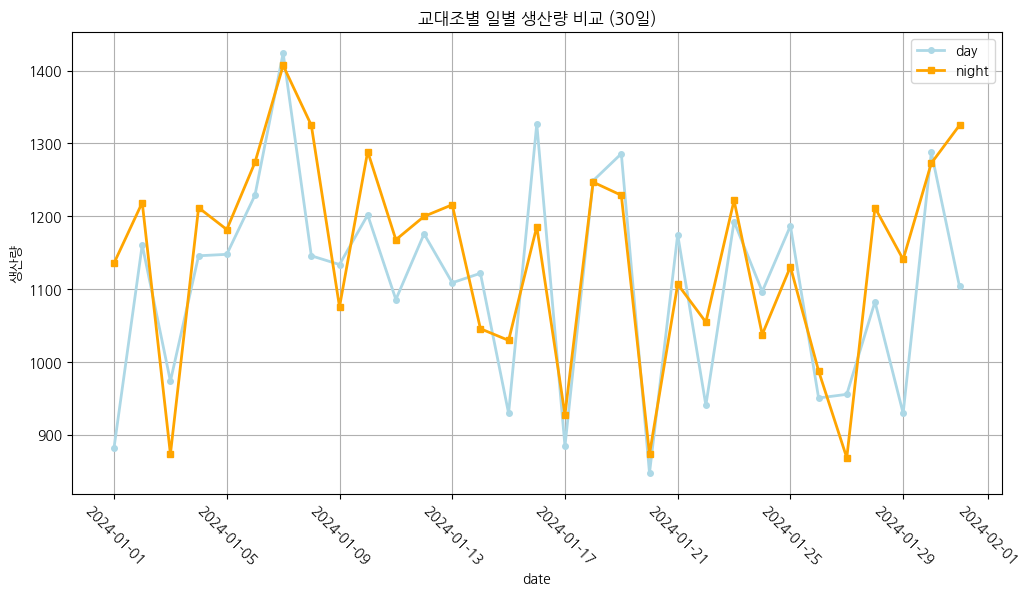

In [85]:
# 여기에 코드 작성
end_date = production_df['production_date'].min() + pd.Timedelta(days = 30)
production_df30 = production_df[production_df['production_date'] <= end_date]

day = production_df30[production_df30['shift'] == 'DAY']
night = production_df30[production_df30['shift'] == 'NIGHT']

day_prod = day.groupby('production_date')['actual_quantity'].sum()
night_prod = night.groupby('production_date')['actual_quantity'].sum()

plt.figure(figsize = (12,6))

plt.plot(day_prod.index, day_prod.values,
         marker = 'o',
         color = 'lightblue',
        label = 'day',
        linewidth = 2,
        markersize = 4)
plt.plot(night_prod.index, night_prod.values,
         marker='s',
         color='orange',
        label = 'night',
        linewidth = 2,
        markersize = 4)

plt.title('교대조별 일별 생산량 비교 (30일)')
plt.xlabel('date')
plt.ylabel('생산량')
plt.legend()
plt.grid(True)
plt.xticks(rotation = -45)
plt.show()

---
## 문제 8: 설비 생산 현황 2x1 subplot (20점)

**요구사항**:
설비별 생산 현황을 2개의 subplot으로 구성:

1. **상단 [0]**: 설비별 총 생산량 막대 그래프 (상위 10개)
   - 막대 색상: 'steelblue', 테두리: 'black'
   - 제목: '설비별 총 생산량'
   - x축 레이블 45도 회전
   - y축 격자

2. **하단 [1]**: 설비별 평균 불량률 막대 그래프 (상위 10개)
   - 막대 색상: 'coral', 테두리: 'black'
   - 제목: '설비별 평균 불량률'
   - x축 레이블 45도 회전
   - y축 격자

3. Figure 크기: (12, 10)
4. `plt.tight_layout()` 적용

**힌트**: `fig, axes = plt.subplots(2, 1)`, `axes[0]`, `axes[1]`

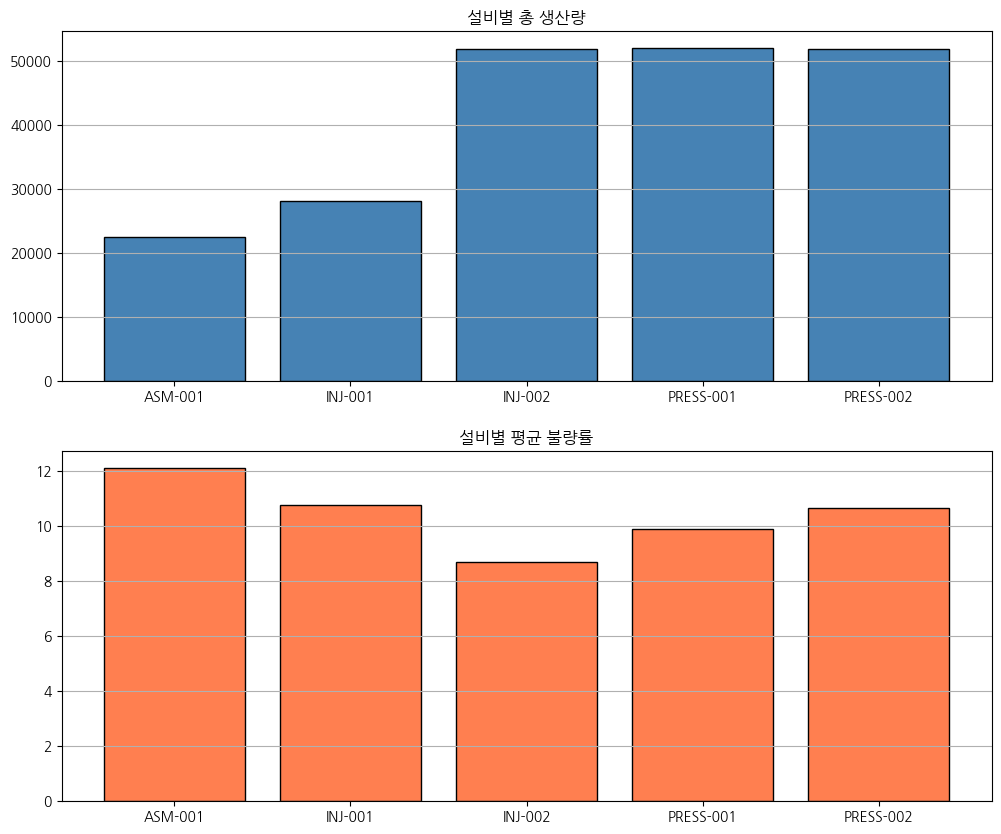

In [93]:
# 여기에 코드 작성
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
equip_prod = production_df.groupby('equipment_id')['actual_quantity'].sum()
equip_defect = production_df.groupby('equipment_id')['불량률'].mean()

axes[0].bar(equip_prod.index, equip_prod.values,
           color = 'steelblue',
           edgecolor = 'black')
axes[0].set_title('설비별 총 생산량', fontsize = 12)
#axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y')

axes[1].bar(equip_defect.index, equip_defect.values,
           color = 'coral',
           edgecolor = 'black')
axes[1].set_title('설비별 평균 불량률', fontsize = 12)
#axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y')


---
## 수고하셨습니다!

### 학습 체크리스트
- [ ] 선 그래프 그리기 및 스타일링
- [ ] 막대 그래프 (세로/가로)
- [ ] 산점도 및 색상 구분
- [ ] 히스토그램 및 통계선 표시
- [ ] 파이 차트
- [ ] 여러 선 그래프 함께 표시
- [ ] Subplot으로 다중 차트 구성
- [ ] 제목, 레이블, 범례, 격자 추가
